In [ ]:

%pip install -q nltk scikit-learn matplotlib pandas numpy
%pip install -q sentencepiece sacrebleu lxml
%pip install torch


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import re
import xml.etree.ElementTree as ET
import sentencepiece as spm
import sacrebleu
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/justinfrancisco/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/justinfrancisco/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/justinfrancisco/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 758, in st

In [ ]:
# Load and parse TMX file
import xml.etree.ElementTree as ET
import re
import os

tmx_filename = "/Users/justinfrancisco/Desktop/CSCI218/Group Project/en-fr.tmx"

if not os.path.exists(tmx_filename):
    raise FileNotFoundError(f"File not found: {tmx_filename}")

print(f"Found file: {tmx_filename}")

def parse_tmx_file(file_path):
    sentences_en, sentences_fr = [], []

    try:
        tree = ET.parse(file_path)
        root = tree.getroot()

        for tu in root.findall('.//tu'):
            seg_en = seg_fr = None
            for tuv in tu.findall('tuv'):
                lang = tuv.get('{http://www.w3.org/XML/1998/namespace}lang', '')
                seg = tuv.find('seg')
                if seg is not None and seg.text:
                    text = re.sub(r'\s+', ' ', seg.text.strip())
                    if lang == 'en':
                        seg_en = text
                    elif lang == 'fr':
                        seg_fr = text

            if seg_en and seg_fr:
                sentences_en.append(seg_en)
                sentences_fr.append(seg_fr)

    except ET.ParseError as e:
        print(f"XML parsing error: {e}")

    print(f"Extracted {len(sentences_en)} English-French sentence pairs")
    return sentences_en, sentences_fr


sentences_en, sentences_fr = parse_tmx_file(tmx_filename)


print("\nSample sentence pairs:")
for i in range(min(3, len(sentences_en))):
    print(f"English {i+1}: {sentences_en[i][:100]}...")
    print(f"French {i+1}: {sentences_fr[i][:100]}...\n")

Found file: /Users/justinfrancisco/Desktop/CSCI218/Group Project/en-fr.tmx
Extracted 2009489 English-French sentence pairs

Sample sentence pairs:
English 1: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I...
French 1: Je déclare reprise la session du Parlement européen qui avait été interrompue le vendredi 17 décembr...

English 2: Although, as you will have seen, the dreaded 'millennium bug' failed to materialise, still the peopl...
French 2: Comme vous avez pu le constater, le grand "bogue de l'an 2000" ne s'est pas produit. En revanche, le...

English 3: You have requested a debate on this subject in the course of the next few days, during this part-ses...
French 3: Vous avez souhaité un débat à ce sujet dans les prochains jours, au cours de cette période de sessio...



In [ ]:
# Data Preprocessing

def clean(s):
    """Clean text"""
    s = s.lower()
    s = re.sub(r"[^\w\s.,!?']", "", s)
    return re.sub(r"\s+", " ", s).strip()

sent_en = [clean(s) for s in sentences_en]
sent_fr = [clean(s) for s in sentences_fr]

MAX_LEN = 20

pairs = [
    (e, f) for e, f in zip(sent_en, sent_fr)
    if 5 < len(e.split()) <= MAX_LEN and 5 < len(f.split()) <= MAX_LEN
]

print(f"Number of filtered sentence pairs: {len(pairs)}")


pairs = random.sample(pairs, 50000)

train, test = train_test_split(pairs, test_size=0.1, random_state=42)
train_en, train_fr = zip(*train)
test_en, test_fr = zip(*test)

print(f"Training set: {len(train_en)}")
print(f"Test set: {len(test_en)}")


with open("bpe_corpus.txt", "w") as f:
    for s in train_en + train_fr:
        f.write(s + "\n")


spm.SentencePieceTrainer.train(
    input="bpe_corpus.txt",
    model_prefix="bpe",
    vocab_size=8000,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)


sp = spm.SentencePieceProcessor()
sp.load("bpe.model")


PAD, UNK, BOS, EOS = 0, 1, 2, 3
MAX_SEQ_LEN = MAX_LEN
PAD_ID = PAD

def encode(s):
    """Encode sentence to token IDs"""
    ids = [BOS] + sp.encode_as_ids(s) + [EOS]
    ids = ids[:MAX_SEQ_LEN]
    return ids + [PAD] * (MAX_SEQ_LEN - len(ids))

def decode(ids):
    """Decode token IDs to text"""
    ids = [i for i in ids if i not in (PAD, BOS, EOS)]
    return sp.decode_ids(ids)


X_train = torch.tensor([encode(s) for s in train_en])
Y_train = torch.tensor([encode(s) for s in train_fr])

X_test = torch.tensor([encode(s) for s in test_en])
Y_test = torch.tensor([encode(s) for s in test_fr])

Number of filtered sentence pairs: 689049
Training set: 45000
Test set: 5000


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: bpe_corpus.txt
  input_format: 
  model_prefix: bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        # Project bidirectional hidden states down for the decoder
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        encoder_outputs, (hidden, cell) = self.lstm(embedded)

        # hidden: [num_layers * 2, batch, hidden_dim]
        # Combine forward and backward directions for each layer
        hidden = torch.cat((hidden[0::2], hidden[1::2]), dim=2)  # [num_layers, batch, hidden_dim*2]
        cell = torch.cat((cell[0::2], cell[1::2]), dim=2)

        hidden = torch.tanh(self.fc_hidden(hidden))  # [num_layers, batch, hidden_dim]
        cell = torch.tanh(self.fc_cell(cell))

        return encoder_outputs, (hidden, cell)


class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim):
        super().__init__()
        self.attn = nn.Linear(encoder_dim + decoder_dim, decoder_dim)
        self.v = nn.Linear(decoder_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: [batch, decoder_dim]
        # encoder_outputs: [batch, src_len, encoder_dim]
        src_len = encoder_outputs.shape[1]
        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((decoder_hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, encoder_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.attention = Attention(encoder_dim, hidden_dim)
        self.lstm = nn.LSTM(
            embed_dim + encoder_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim + encoder_dim + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        # x: [batch] single token per step
        x = x.unsqueeze(1)  # [batch, 1]
        embedded = self.dropout(self.embedding(x))  # [batch, 1, embed_dim]

        # Attention over encoder outputs using top-layer hidden state
        attn_weights = self.attention(hidden[-1], encoder_outputs)  # [batch, src_len]
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # [batch, 1, encoder_dim]

        lstm_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc(torch.cat((output, context, embedded), dim=2).squeeze(1))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)
        encoder_outputs, (hidden, cell) = self.encoder(src)

        # First decoder input is the BOS token
        input_token = trg[:, 0]

        for t in range(1, trg_len):
            prediction, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t] = prediction

            # Teacher forcing: use ground truth or model's own prediction
            if random.random() < teacher_forcing_ratio:
                input_token = trg[:, t]
            else:
                input_token = prediction.argmax(1)

        return outputs

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

EMBED_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3
ENCODER_DIM = HIDDEN_DIM * 2  # bidirectional

encoder = Encoder(sp.vocab_size(), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
decoder = Decoder(sp.vocab_size(), EMBED_DIM, HIDDEN_DIM, ENCODER_DIM, NUM_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total model parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test forward pass
print("\nTesting model forward pass...")
test_batch_size = 4
test_src = X_train[:test_batch_size].to(device)
test_trg = Y_train[:test_batch_size].to(device)

try:
    model.eval()
    with torch.no_grad():
        outputs = model(test_src, test_trg, teacher_forcing_ratio=0)
        print(f"Output shape: {outputs.shape}")
        print("Model forward pass successful")
except Exception as e:
    print(f"Model error: {e}")

from torch.utils.data import DataLoader

train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

losses, bleus = [], []
best_bleu = 0
current_lr = optimizer.param_groups[0]['lr']

print("\nStarting Seq2Seq model training...")
print(f"Initial learning rate: {current_lr:.6f}")
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    # Decrease teacher forcing over time
    teacher_forcing_ratio = max(0.3, 1.0 - epoch * 0.05)

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}')
    for src_batch, trg_batch in pbar:
        src_batch, trg_batch = src_batch.to(device), trg_batch.to(device)

        optimizer.zero_grad()

        outputs = model(src_batch, trg_batch, teacher_forcing_ratio=teacher_forcing_ratio)

        # Skip the first token (BOS) for loss calculation
        loss = criterion(
            outputs[:, 1:].reshape(-1, sp.vocab_size()),
            trg_batch[:, 1:].reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    # Evaluate BLEU
    model.eval()
    hypotheses, references = [], []

    with torch.no_grad():
        for src_batch, trg_batch in test_loader:
            src_batch = src_batch.to(device)
            trg_batch = trg_batch.to(device)

            # Use no teacher forcing for evaluation
            outputs = model(src_batch, trg_batch, teacher_forcing_ratio=0)
            predictions = torch.argmax(outputs, dim=-1)

            for j in range(src_batch.size(0)):
                pred_seq = predictions[j].cpu().tolist()
                ref_seq = trg_batch[j].cpu().tolist()

                hyp_text = decode(pred_seq)
                ref_text = decode(ref_seq)

                hypotheses.append(hyp_text)
                references.append([ref_text])

    if hypotheses and references:
        try:
            bleu = sacrebleu.corpus_bleu(hypotheses, references).score
        except:
            bleu = 0
    else:
        bleu = 0

    bleus.append(bleu)

    old_lr = current_lr
    scheduler.step(bleu)
    current_lr = optimizer.param_groups[0]['lr']

    lr_change_msg = ""
    if abs(current_lr - old_lr) > 1e-9:
        lr_change_msg = f" | LR change: {old_lr:.6f} -> {current_lr:.6f}"

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | BLEU: {bleu:.2f} | TF: {teacher_forcing_ratio:.2f} | LR: {current_lr:.6f}{lr_change_msg}")

    if bleu > best_bleu:
        best_bleu = bleu
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'bleu': bleu,
            'model_config': {
                'vocab_size': sp.vocab_size(),
                'embed_dim': EMBED_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'dropout': DROPOUT,
                'encoder_dim': ENCODER_DIM,
                'max_seq_len': MAX_SEQ_LEN
            }
        }, 'best_seq2seq_model.pth')
        print(f"  Saved best model, BLEU: {bleu:.2f}")

Using device: mps
Total model parameters: 13,497,152
Trainable parameters: 13,497,152

Testing model forward pass...
Output shape: torch.Size([4, 20, 8000])
Model forward pass successful

Starting Seq2Seq model training...
Initial learning rate: 0.001000


Epoch 01: 100%|██████████| 352/352 [02:17<00:00,  2.57it/s, loss=4.81]


Epoch 01 | Loss: 5.437 | BLEU: 52.92 | TF: 1.00 | LR: 0.001000
  Saved best model, BLEU: 52.92


Epoch 02: 100%|██████████| 352/352 [02:58<00:00,  1.98it/s, loss=4.19]


Epoch 02 | Loss: 4.353 | BLEU: 53.29 | TF: 0.95 | LR: 0.001000
  Saved best model, BLEU: 53.29


...

Epoch 13 | Loss: 3.517 | BLEU: 42.85 | TF: 0.40 | LR: 0.000250


Epoch 14: 100%|██████████| 352/352 [04:06<00:00,  1.43it/s, loss=3.24]


Epoch 14 | Loss: 3.573 | BLEU: 42.11 | TF: 0.35 | LR: 0.000125 | LR change: 0.000250 -> 0.000125


Epoch 15: 100%|██████████| 352/352 [03:56<00:00,  1.49it/s, loss=3.82]


Epoch 15 | Loss: 3.654 | BLEU: 38.41 | TF: 0.30 | LR: 0.000125


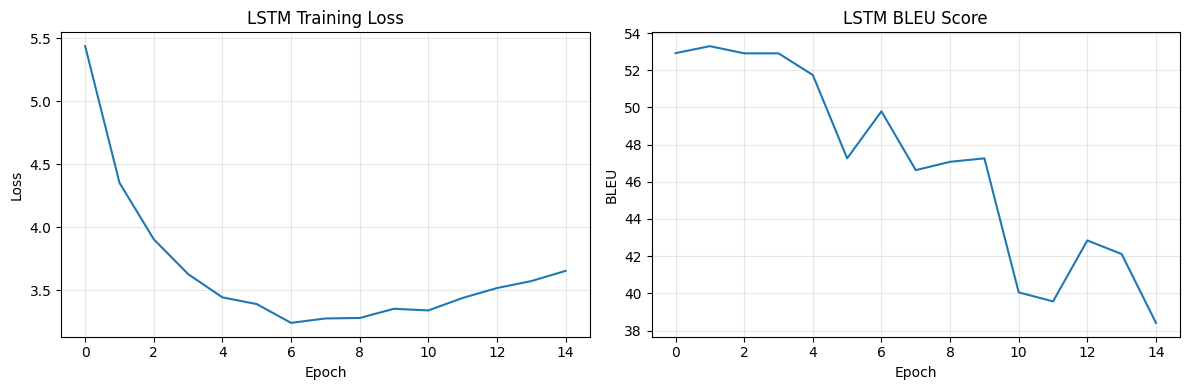

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if len(bleus) > 0:
    plt.plot(bleus)
    plt.title('LSTM BLEU Score')
    plt.xlabel('Epoch')
    plt.ylabel('BLEU')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

def translate(sentence, verbose=False):
    """
    Translation function using autoregressive decoding.
    The encoder reads the full English sentence, then the decoder
    generates French tokens one at a time.
    """
    model.eval()

    clean_sent = clean(sentence)
    encoded = encode(clean_sent)

    if verbose:
        print(f"Cleaned input: {clean_sent}")
        print(f"Encoded IDs: {encoded[:10]}...")

    src_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        # Encode the full source sentence
        encoder_outputs, (hidden, cell) = model.encoder(src_tensor)

        # Start decoding with BOS token
        input_token = torch.tensor([BOS], dtype=torch.long).to(device)

        result = []
        for _ in range(MAX_SEQ_LEN):
            prediction, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)
            top1 = prediction.argmax(1)

            if top1.item() == EOS:
                break

            result.append(top1.item())
            input_token = top1

    return sp.decode_ids(result)


print("\n" + "="*50)
print("Translation Test Examples")
print("="*50)

test_sentences = [
    "I declare resumed the session",
    "Hello how are you",
    "The cat is on the table",
    "This is a test",
    "Machine translation"
]

for i, sentence in enumerate(test_sentences):
    try:
        translation = translate(sentence)
        print(f"\nTest {i+1}:")
        print(f"  English: {sentence}")
        print(f"  French: {translation}")
    except Exception as e:
        print(f"Translation error: {e}")


Translation Test Examples

Test 1:
  English: I declare resumed the session
  French: je déclare reprise la la la la

Test 2:
  English: Hello how are you
  French: les' de la t ⁇ ches sont

Test 3:
  English: The cat is on the table
  French: le est est la sur la table

Test 4:
  English: This is a test
  French: c'est une'un de

Test 5:
  English: Machine translation
  French: la de de la traduction de la traduction


In [ ]:
import json
from datetime import datetime

# Compute metrics on test set
model.eval()
all_preds, all_refs = [], []

with torch.no_grad():
    for src_batch, trg_batch in test_loader:
        src_batch = src_batch.to(device)
        trg_batch = trg_batch.to(device)

        outputs = model(src_batch, trg_batch, teacher_forcing_ratio=0)
        predictions = torch.argmax(outputs[:, 1:], dim=-1).cpu().tolist()
        references = trg_batch[:, 1:].cpu().tolist()

        for pred, ref in zip(predictions, references):
            # Filter out PAD tokens
            for p, r in zip(pred, ref):
                if r != PAD:
                    all_preds.append(p)
                    all_refs.append(r)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_refs, all_preds, average='weighted', zero_division=0
)
accuracy = sum(p == r for p, r in zip(all_preds, all_refs)) / len(all_refs)

metrics = {
    'accuracy': accuracy,
    'weighted_precision': precision,
    'weighted_recall': recall,
    'weighted_f1': f1
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

training_results = {
    'timestamp': timestamp,
    'model_name': 'Seq2SeqTranslationModel',
    'vocab_size': sp.vocab_size(),
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'max_seq_len': MAX_SEQ_LEN,
    'num_epochs': len(losses),
    'losses': losses,
    'bleus': bleus,
    'final_loss': losses[-1] if losses else None,
    'final_bleu': bleus[-1] if bleus else None,
    'best_bleu': best_bleu,
    'training_samples': len(X_train),
    'testing_samples': len(X_test),
    'metrics': metrics
}

with open(f'seq2seq_training_results_{timestamp}.json', 'w') as f:
    json.dump(training_results, f, indent=2)


model_save_path = f'seq2seq_translation_model_{timestamp}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'vocab_size': sp.vocab_size(),
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'encoder_dim': ENCODER_DIM,
        'max_seq_len': MAX_SEQ_LEN
    },
    'training_results': training_results,
    'bpe_model_path': 'bpe.model'
}, model_save_path)

print(f"\n{'='*50}")
print("Seq2Seq Training Completed!")
print(f"{'='*50}")
print(f"Training results saved to: seq2seq_training_results_{timestamp}.json")
print(f"Model saved to: {model_save_path}")
print(f"\nKey Metrics:")
print(f"  - Final training loss: {losses[-1]:.3f}" if losses else "  - Training loss: N/A")
print(f"  - Final BLEU score: {bleus[-1]:.2f}" if bleus else "  - BLEU score: N/A")
print(f"  - Best BLEU score: {best_bleu:.2f}" if best_bleu else "  - Best BLEU: N/A")
print(f"  - Token Accuracy: {metrics['accuracy']:.4f}")
print(f"  - Weighted F1-Score: {metrics['weighted_f1']:.4f}")
print(f"  - Total training samples: {len(X_train)}")
print(f"  - Total testing samples: {len(X_test)}")
print(f"{'='*50}")


Seq2Seq Training Completed!
Training results saved to: seq2seq_training_results_20260210_103652.json
Model saved to: seq2seq_translation_model_20260210_103652.pth

Key Metrics:
  - Final training loss: 3.654
  - Final BLEU score: 38.41
  - Best BLEU score: 53.29
  - Token Accuracy: 0.1718
  - Weighted F1-Score: 0.1523
  - Total training samples: 45000
  - Total testing samples: 5000
